# ROSE-1 SVC — Classical Baseline (Raw vs. Preprocessed)

Applies the locked-in adaptive-threshold baseline (params from
`preprocessing/ROSE_preprocess_grid_search.ipynb`) to the 9 held-out ROSE-1
SVC test images, with and without CLAHE+median preprocessing, and compares
the two on the full metric suite plus a few qualitative examples.


## Without preprocessing

In [9]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from classical_baseline import segment_adaptive, evaluate_on_test
from evaluate import dice

ROSE1 = Path("/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1")

test_imgs  = sorted((ROSE1 / "SVC/test/img").glob("*.tif"))
test_masks = sorted((ROSE1 / "SVC/test/gt").glob("*.tif"))

# Best params found via grid search (cross-validated, on training data)
PREP_BLOCK, PREP_C = 101, -30      # preprocessed
PREP_CLIP, PREP_TILE = 2.0, 4

RAW_BLOCK, RAW_C = 101, -30

In [10]:
# Preprocessed (apply CLAHE in-pipeline)
prep_mean, prep_std = evaluate_on_test(
    test_imgs, test_masks, PREP_BLOCK, PREP_C, clip=PREP_CLIP, tile=PREP_TILE
)

# Raw (no preprocessing)
raw_mean, raw_std = evaluate_on_test(
    test_imgs, test_masks, RAW_BLOCK, RAW_C
)

print("="*55)
print(f"RAW classical (block={RAW_BLOCK}, C={RAW_C}) — TEST")
print("="*55)
for k in raw_mean:
    print(f"  {k}: {raw_mean[k]:.4f} ± {raw_std[k]:.4f}")

print("\n" + "="*55)
print(f"PREPROCESSED classical (block={PREP_BLOCK}, C={PREP_C}, "
      f"clip={PREP_CLIP}, tile={PREP_TILE}) — TEST")
print("="*55)
for k in prep_mean:
    print(f"  {k}: {prep_mean[k]:.4f} ± {prep_std[k]:.4f}")

RAW classical (block=101, C=-30) — TEST
  dice: 0.6330 ± 0.0222
  iou: 0.4635 ± 0.0238
  sensitivity: 0.7045 ± 0.0561
  specificity: 0.8854 ± 0.0166
  precision: 0.5795 ± 0.0396

PREPROCESSED classical (block=101, C=-30, clip=2.0, tile=4) — TEST
  dice: 0.6714 ± 0.0278
  iou: 0.5060 ± 0.0316
  sensitivity: 0.6980 ± 0.0665
  specificity: 0.9167 ± 0.0110
  precision: 0.6518 ± 0.0300


In [11]:
print(f"{'Metric':<14}{'Raw':<20}{'Preprocessed':<20}")
print("-"*54)
for k in raw_mean:
    raw_str  = f"{raw_mean[k]:.4f} ± {raw_std[k]:.4f}"
    prep_str = f"{prep_mean[k]:.4f} ± {prep_std[k]:.4f}"
    print(f"{k:<14}{raw_str:<20}{prep_str:<20}")

Metric        Raw                 Preprocessed        
------------------------------------------------------
dice          0.6330 ± 0.0222     0.6714 ± 0.0278     
iou           0.4635 ± 0.0238     0.5060 ± 0.0316     
sensitivity   0.7045 ± 0.0561     0.6980 ± 0.0665     
specificity   0.8854 ± 0.0166     0.9167 ± 0.0110     
precision     0.5795 ± 0.0396     0.6518 ± 0.0300     


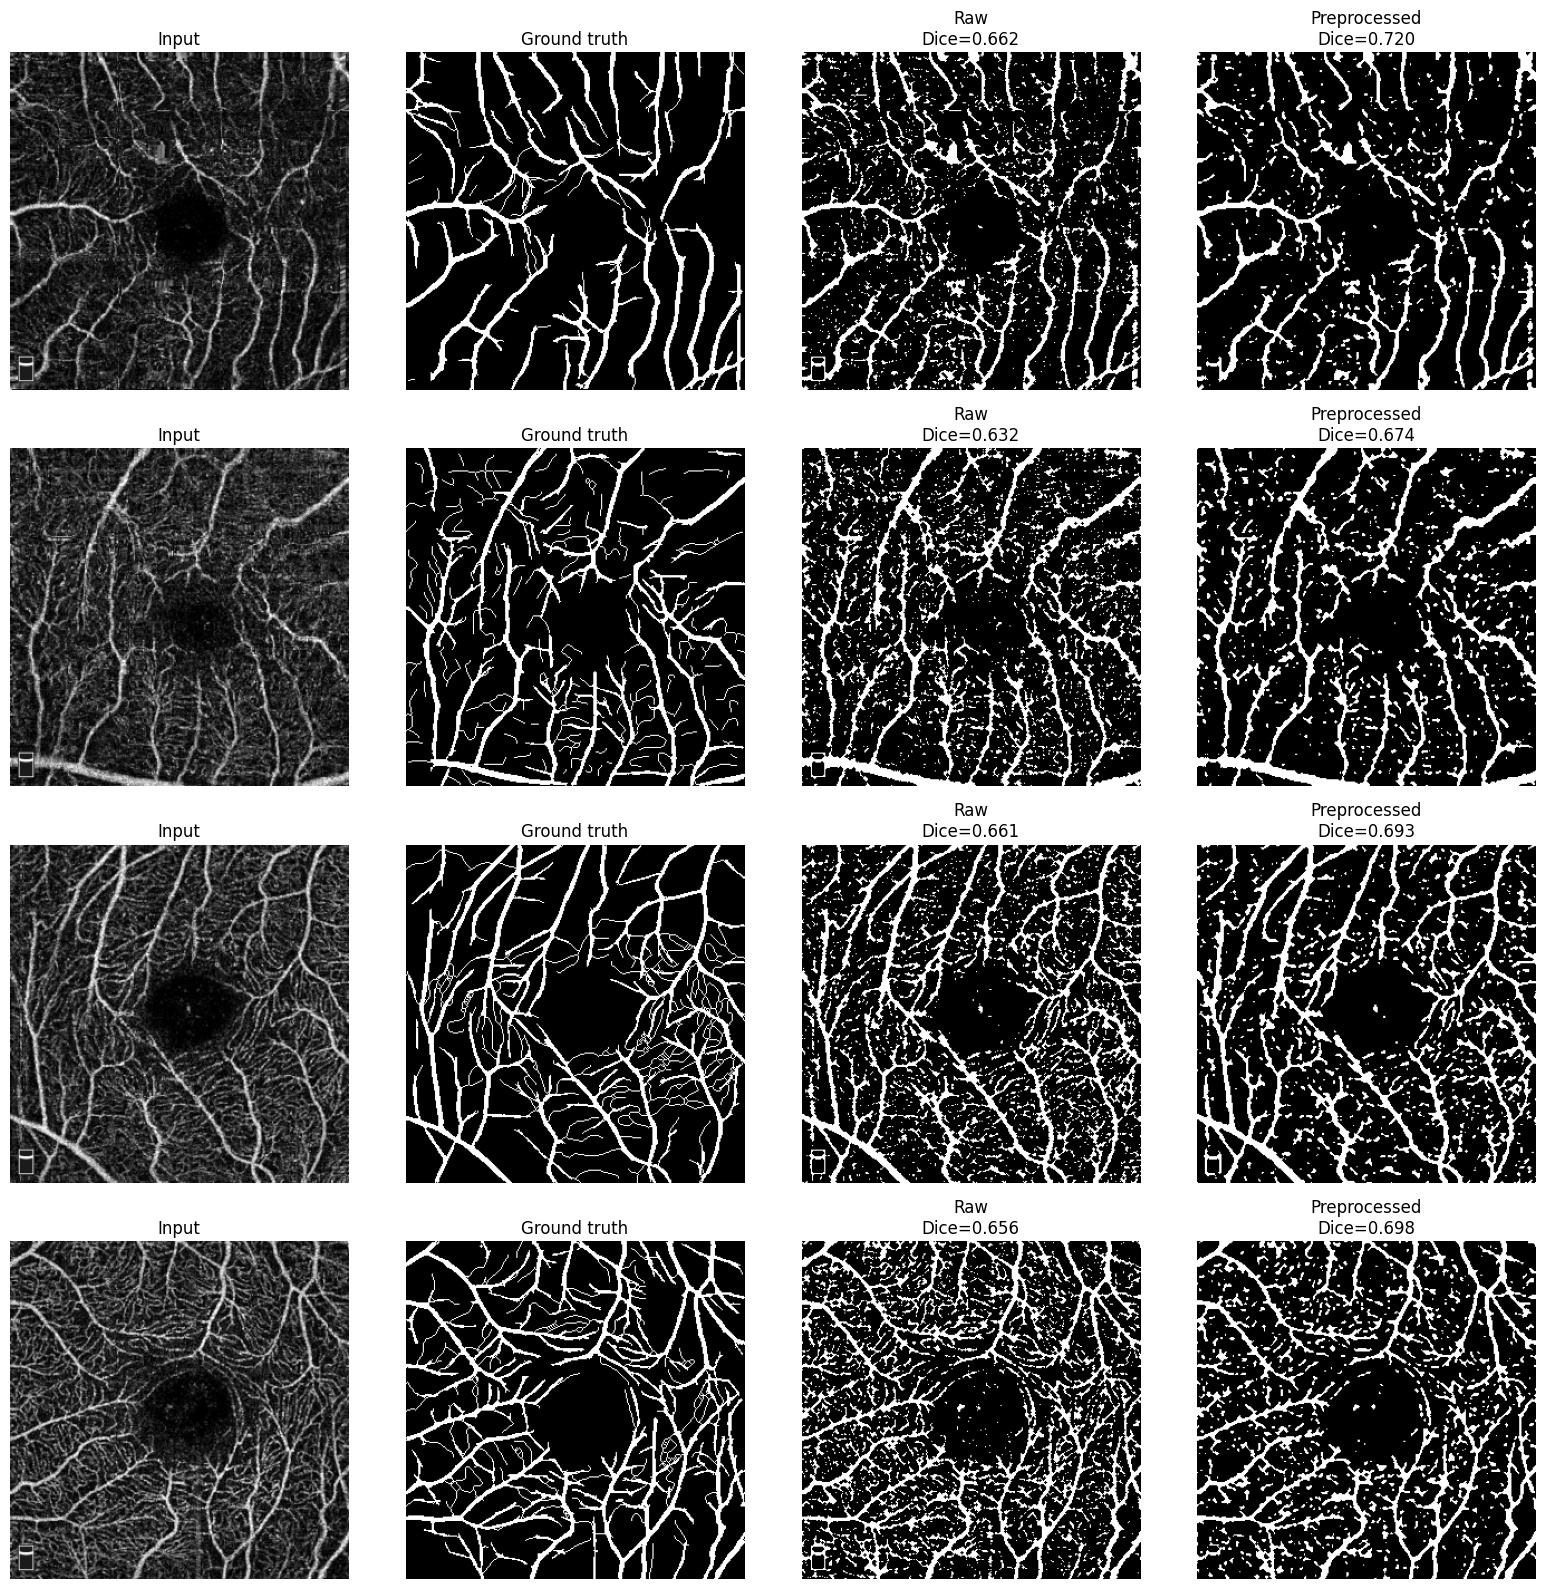

In [12]:
n_show = 4
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))

for i in range(n_show):
    img = cv2.imread(str(test_imgs[i]),  cv2.IMREAD_GRAYSCALE)
    gt  = cv2.imread(str(test_masks[i]), cv2.IMREAD_GRAYSCALE)

    pred_raw  = segment_adaptive(img, RAW_BLOCK, RAW_C)
    pred_prep = segment_adaptive(img, PREP_BLOCK, PREP_C,
                                 clip=PREP_CLIP, tile=PREP_TILE)

    axes[i,0].imshow(img,  cmap='gray'); axes[i,0].set_title("Input")
    axes[i,1].imshow(gt,   cmap='gray'); axes[i,1].set_title("Ground truth")
    axes[i,2].imshow(pred_raw,  cmap='gray')
    axes[i,2].set_title(f"Raw\nDice={dice(pred_raw, gt):.3f}")
    axes[i,3].imshow(pred_prep, cmap='gray')
    axes[i,3].set_title(f"Preprocessed\nDice={dice(pred_prep, gt):.3f}")
    for c in range(4):
        axes[i,c].axis('off')

plt.tight_layout()
plt.savefig('results/classical_raw_vs_prep_comparison.png', dpi=150)
plt.show()